In [3]:
#NAME-SANIYA GOUTAM PRN-23070521126
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os
df = pd.read_csv(os.path.join(path, "data.csv"))
columns_to_drop = ["id"]
if 'Unnamed: 32' in df.columns:
    columns_to_drop.append('Unnamed: 32')
df.drop(columns_to_drop, axis=1, inplace=True)

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])

# Features and Target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]
if X.isnull().sum().sum() > 0:
    print("Warning: NaNs found in features. Imputing with mean.")
    X.fillna(X.mean(), inplace=True)
constant_columns = X.columns[X.std() == 0]
if not constant_columns.empty:
    print(f"Dropping constant columns: {list(constant_columns)}")
    X.drop(columns=constant_columns, inplace=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Model 1 : 3 Layer Deep Feed Forward Network

model3 = Sequential()
model3.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    verbose=1
)
y_pred3 = model3.predict(X_test)
y_pred3 = (y_pred3 > 0.5).astype(int)

print("\n----- 3 Layer Model -----")
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred3))
# Model 2 : 5 Layer Deep Feed Forward Network
model5 = Sequential()
model5.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model5.add(Dense(64, activation='relu'))
model5.add(Dense(32, activation='relu'))
model5.add(Dense(16, activation='relu'))
model5.add(Dense(1, activation='sigmoid'))
model5.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history5 = model5.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    verbose=1
)
y_pred5 = model5.predict(X_test)
y_pred5 = (y_pred5 > 0.5).astype(int)
print("\n----- 5 Layer Model -----")
print("Accuracy:", accuracy_score(y_test, y_pred5))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred5))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8110 - loss: 0.5200
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9363 - loss: 0.2675 
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9429 - loss: 0.1763 
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9560 - loss: 0.1360 
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9626 - loss: 0.1141 
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9692 - loss: 0.0993 
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9714 - loss: 0.0875 
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9780 - loss: 0.0784 
Epoch 9/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9780 - loss: 0.0725 
Epoch 10/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9802 - loss: 0.0657 
Epoch 11/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0614 
Epoch 12/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9846 - los

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

----- 3 Layer Model -----
Accuracy: 0.9824561403508771
Confusion Matrix:
[[71  0]
 [ 2 41]]
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8835 - loss: 0.4681
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9516 - loss: 0.1694 
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9758 - loss: 0.0920 
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9824 - loss: 0.0642 
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9890 - loss: 0.0512 
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9868 - loss: 0.0454 
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9912 - loss: 0.0372 
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9934 - loss: 0.0310 
Epoch 9/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9934 - loss: 0.0255 
Epoch 10/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9956 - loss: 0.0220 
Epoch 11/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9934 - loss: 0.0193 
Epoch 12/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9956 - los

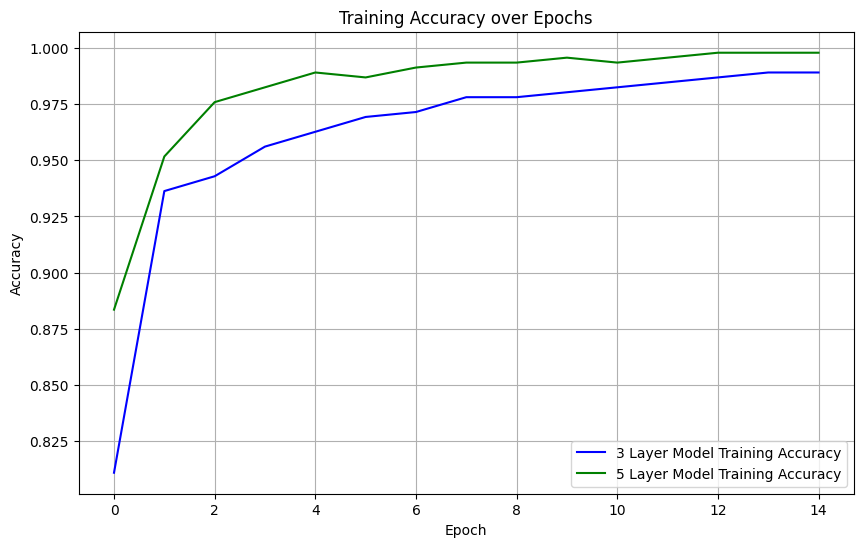

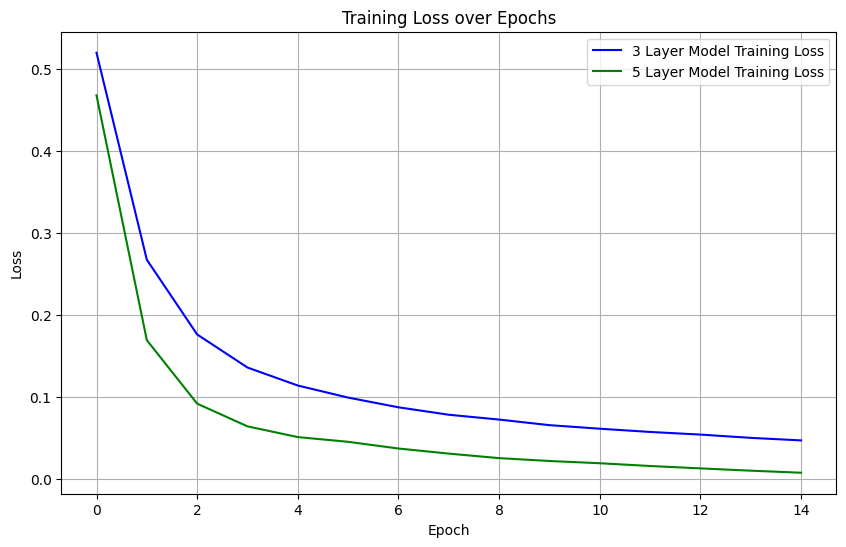

In [11]:
import matplotlib.pyplot as plt

# Plotting Training Accuracy for both models (Line Graph)
plt.figure(figsize=(10, 6))
plt.plot(history3.history['accuracy'], label='3 Layer Model Training Accuracy', color='blue')
plt.plot(history5.history['accuracy'], label='5 Layer Model Training Accuracy', color='green')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Training Loss for both models (Line Graph)
plt.figure(figsize=(10, 6))
plt.plot(history3.history['loss'], label='3 Layer Model Training Loss', color='blue')
plt.plot(history5.history['loss'], label='5 Layer Model Training Loss', color='green')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()